## Deep Set Embedding Tutorial
This tutorial demonstrates how to use the lampe backend with a custom Deep Set embedding network.

In [1]:
%load_ext autoreload
%autoreload 2

# Standard library and deep learning imports
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils import data
# PyTorch Geometric imports for graph/set data
from torch_geometric.data import Data as PYGData
from torch_geometric.loader.dataloader import Collater
from torch_geometric.nn import global_mean_pool, global_max_pool

# ltu-ili imports for inference and validation
import ili
from ili.dataloaders import TorchLoader
from ili.inference import InferenceRunner
from ili.validation.metrics import PlotSinglePosterior, PosteriorCoverage

# Set device for PyTorch (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2026-03-31 14:47:56.572898: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774982876.594654   70394 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774982876.600960   70394 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 14:47:56.623538: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Toy Point Set Dataset
We generate sets of 2D points. Each set is drawn from a normal distribution with a random center. 
The task is to predict the center coordinates (theta) from the unordered set of points.


In [2]:
# Dataset generation parameters
num_samples = 2000
avg_points_per_set = 10
dim_theta = 2

dataset = []
thetas = []
for _ in range(num_samples):
    # Generate a variable number of points per set (Poisson distributed)
    num_points_per_set = np.random.poisson(avg_points_per_set)
    # Sample the center coordinates (theta) from a uniform prior
    theta = np.random.uniform(-3, 3, size=dim_theta)
    # Generate points around the center with some Gaussian noise
    points = np.random.randn(num_points_per_set, dim_theta) * 0.5 + theta

    x_tensor = torch.tensor(points, dtype=torch.float32)
    y_tensor = torch.tensor(theta, dtype=torch.float32)[None, :]

    # Convert to PyTorch Geometric Data object for variable-sized sets
    dataset.append(PYGData(x=x_tensor, y=y_tensor))
    thetas.append(y_tensor)
# Collect all true thetas for later evaluation
thetas = np.concatenate(thetas, axis=0)

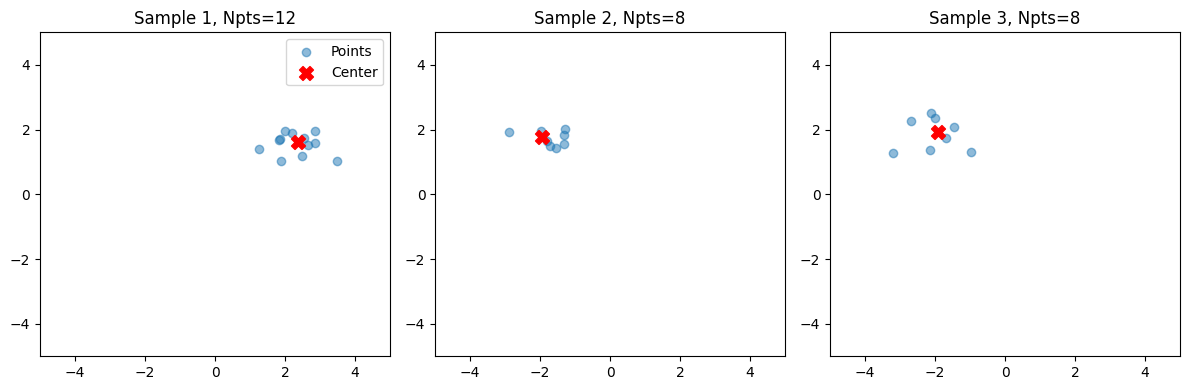

In [3]:

# Plot the first 3 samples from the dataset to visualize the points and their centers
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    data_sample = dataset[i]
    x_pts = data_sample.x.numpy()
    theta_val = data_sample.y.numpy().flatten()

    axes[i].scatter(x_pts[:, 0], x_pts[:, 1], alpha=0.5, label='Points')
    axes[i].scatter(theta_val[0], theta_val[1], color='red',
                    marker='X', s=100, label='Center')
    axes[i].set_xlim(-5, 5)
    axes[i].set_ylim(-5, 5)
    axes[i].set_title(f'Sample {i+1}, Npts={(len(x_pts))}')
    if i == 0:
        axes[i].legend()
plt.tight_layout()
plt.show()

In [4]:
# Define custom dataset and dataloaders

# PyTorch Dataset wrapper for our generated point sets
class GraphData(data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


graph_dataset = GraphData(dataset)
# Use PyTorch Geometric's Collater to handle batching of variable-size sets
collater = Collater(dataset=graph_dataset, follow_batch='y')


def collate_fn(batch):
    batch = collater(batch)
    return batch, batch.y


# Define train/validation split indices
validation_fraction = 0.1
n_train = int((1 - validation_fraction) * len(graph_dataset))
permuted_idx = np.random.permutation(len(graph_dataset))
idx_train = permuted_idx[:n_train]
idx_val = permuted_idx[n_train:]

# Create PyTorch DataLoaders for training and validation
train_loader = data.DataLoader(
    graph_dataset, batch_size=32, collate_fn=collate_fn,
    sampler=data.SubsetRandomSampler(idx_train), drop_last=True
)
val_loader = data.DataLoader(
    graph_dataset, batch_size=32, collate_fn=collate_fn,
    sampler=data.SubsetRandomSampler(idx_val)
)

# Wrap the PyTorch DataLoaders in an ltu-ili TorchLoader
loader = TorchLoader(train_loader, val_loader)

In [5]:
# Design a simple Deep Set embedder

class DeepSet(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # Node MLP applied independently to each point/node
        self.node_mlp = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels)
        )
        # Global MLP applied to the aggregated global features
        self.global_mlp = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels)
        )

    def forward(self, x):
        node_features, batch = x.x, x.batch

        # Apply node-wise transformation
        node_embed = self.node_mlp(node_features)

        # Pool features globally using both mean and max to ensure permutation invariance
        mean_pool = global_mean_pool(node_embed, batch)
        max_pool = global_max_pool(node_embed, batch)
        # Concatenate pooled features and apply global transformation
        global_embed = torch.cat([mean_pool, max_pool], dim=1)
        return self.global_mlp(global_embed)


embedding = DeepSet(in_channels=dim_theta, hidden_channels=32, out_channels=8)

In [6]:
# Define a uniform prior over the parameter space
prior = ili.utils.Uniform(
    low=[-3] * dim_theta, high=[3] * dim_theta, device=device
)

# Define Neural Density Estimators (NDEs) - here using Neural Spline Flows (NSF)
nets = [
    ili.utils.load_nde_lampe(
        model='nsf', hidden_features=32, num_transforms=3,
        # Pass the custom Deep Set embedding network to compress the data
        embedding_net=embedding, x_normalize=False, device=device
    )
]

# Specify training hyperparameters
train_args = {
    'training_batch_size': 32,
    'learning_rate': 1e-4,
    'stop_after_epochs': 20
}

# Initialize the inference runner with the 'lampe' backend for Neural Posterior Estimation (NPE)
runner = InferenceRunner.load(
    backend='lampe',
    engine='NPE',
    prior=prior,
    nets=nets,
    device=device,
    train_args=train_args,
    proposal=None,
    out_dir=None
)

In [7]:
# Run the inference training process to learn the posterior
posterior_ensemble, summaries = runner(loader=loader)

INFO:root:MODEL INFERENCE CLASS: NPE
INFO:root:Training model 1 / 1.
0 epochs [00:00, ? epochs/s]/home/puehlengt/.local/lib/python3.11/site-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
143 epochs [05:52,  2.46s/ epochs, loss=-0.805, loss_val=-0.696]
INFO:root:It took 352.39102578163147 seconds to train models.


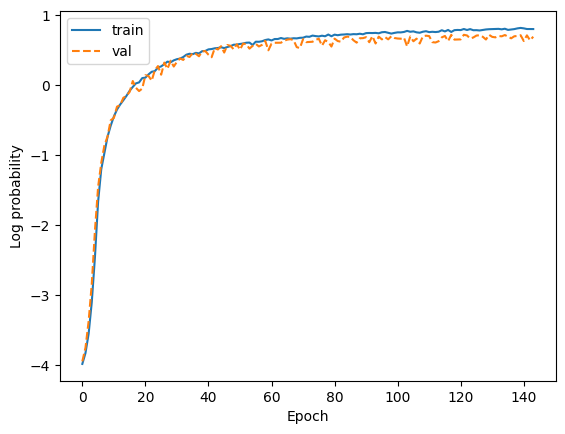

In [8]:

# Plot training and validation log probabilities over epochs
fig, ax = plt.subplots()
for i, m in enumerate(summaries):
    ax.plot(m['training_log_probs'], ls='-', label="train")
    ax.plot(m['validation_log_probs'], ls='--', label="val")
ax.set_xlabel('Epoch')
ax.set_ylabel('Log probability')
ax.legend()

In [9]:

# Select a single validation sample to evaluate
ind = 0
val_idx = idx_val[ind]
x_ = graph_dataset[val_idx]
# Get the true parameter values
y_ = x_.y[0].numpy()

torch.manual_seed(1234)
# Sample from the trained posterior ensemble
samples = posterior_ensemble.sample((1000,), x_)
# Evaluate the log probability of the samples
log_prob = posterior_ensemble.log_prob(samples, x_)

samples = samples.cpu().numpy()
log_prob = log_prob.cpu().numpy()

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 27582.49it/s]


In [ ]:
type(samples), samples.shape, log_prob.shape, samples[0]

AttributeError: 'GlobalStorage' object has no attribute 'shape'

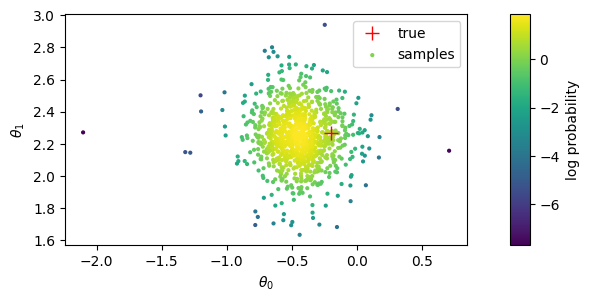

In [10]:
# Visualize the 2D posterior samples compared to the true value
fig, axs = plt.subplots(1, dim_theta, figsize=(3*dim_theta, 3),
                        gridspec_kw={'width_ratios': [1]*(dim_theta-1)+[0.05]})
if dim_theta == 2:
    axs[0].plot(y_[0], y_[1], 'r+', markersize=10, label='true')
    im = axs[0].scatter(samples[:, 0], samples[:, 1],
                        c=log_prob, s=4, label='samples')
    axs[0].set_xlabel(r'$\theta_0$')
    axs[0].set_ylabel(r'$\theta_1$')
    axs[0].legend()
    plt.colorbar(im, label='log probability', use_gridspec=True, cax=axs[-1])

INFO:root:Sampling models with [1000] samples each.
Drawing 1000 posterior samples: 100%|██████████| 1000/1000 [00:00<00:00, 80840.03it/s]


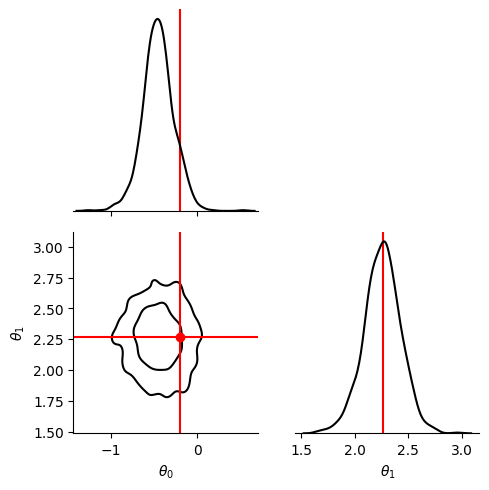

In [11]:

metric = PlotSinglePosterior(
    num_samples=1000, sample_method='direct',
    labels=[f'$\\theta_{i}$' for i in range(dim_theta)]
)
fig = metric(
    posterior=posterior_ensemble,
    x_obs=x_, theta_fid=y_
)

 16%|█▌        | 315/2000 [00:06<00:32, 52.44it/s]/home/puehlengt/ltu-ili/ili/utils/ndes_pt.py:206: UserWarning: Direct sampling took too long. The posterior is poorly constrained within the prior support. Consider using emcee sampling or using a larger prior support. Returning prior samples.
  warnings.warn(
100%|██████████| 100/100 [00:18<00:00,  5.55it/s]


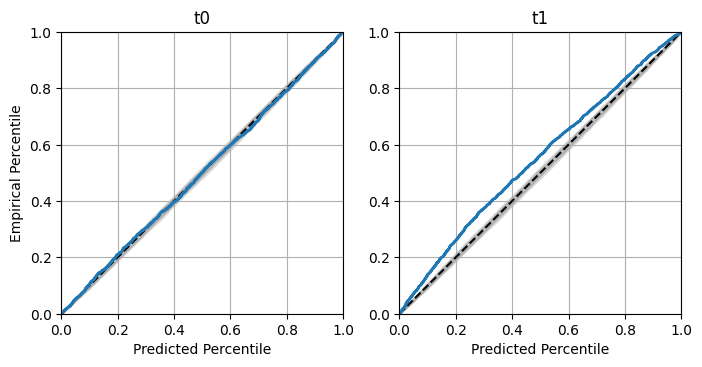

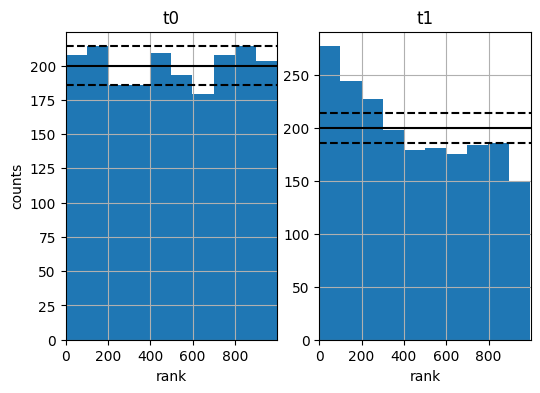

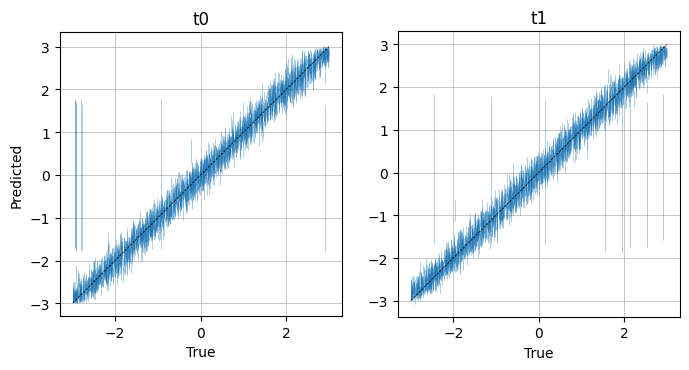

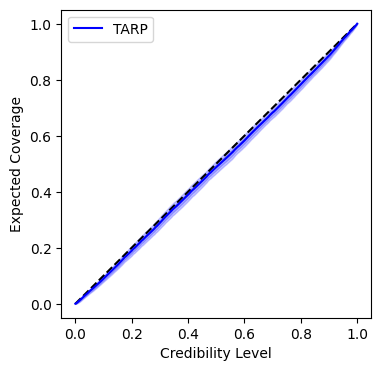

In [12]:
# PosteriorCoverage
metric = PosteriorCoverage(
    num_samples=1000, sample_method='direct',
    out_dir=None, labels=[f't{i}' for i in range(dim_theta)],
    plot_list=["coverage", "histogram", "predictions", "tarp"],
    save_samples=True
)
fig = metric(
    posterior=posterior_ensemble,
    x=graph_dataset, theta=thetas
)